# Initialisation

* `src()` works well in the previous workflow whereas the current call does not (with yellow wave under the functions which actually are called).

In [8]:
year          = 2023
loc_json = "json/location_params.json"
geo_json      = 'json/geo_params.json'
default_json  = 'json/default_params.json'
config_json   = 'json/UQ_null.json'
epw_path      = '../_data/_epw/ED-TMYx.2023.epw'
occupancyProfile_csv = '../RC_BuildingSimulator/rc_simulator/auxiliary/schedules_el_OFFICE.csv'

In [9]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import json

ROOT = Path.cwd().parent.resolve()
RC_SIMULATOR = ROOT / "RC_BuildingSimulator" / "rc_simulator"
if str(RC_SIMULATOR) not in sys.path:
    sys.path.insert(0, str(RC_SIMULATOR))

In [10]:
from building_physics import Zone
import supply_system
import emission_system
from radiation import Location, Window
from _BR_ import *
CITYLOC       = json.loads(Path(loc_json).read_text())
EDI            = Location(epwfile_path=epw_path)
GEOMETRY       = json.loads(Path(geo_json).read_text())
DEFAULT_PARAMS = json.loads(Path(default_json).read_text())
occupancyProfile = pd.read_csv(occupancyProfile_csv)


In [11]:
meter_path = "../_data/Metering_ISO.csv"
meter_daily = load_meter_heating(meter_path, "Main Heating", GEOMETRY["FLOOR_AREA"], "D")
meter_hourly = load_meter_heating(meter_path, "Main Heating", GEOMETRY["FLOOR_AREA"], "h")

Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00
Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00


# ETH_package

* Ventilation is not calculated as an airflow network. It is simplified into a single heat-loss conductance between indoor air and supply/outdoor air
* Parameter definition
    * "_alpha"     :     3,   # coefficient for 'area of surfaces facing the room'
    * "_beta"      :     0.3, # coefficient for 'south windows'

In [ ]:
def run_model(sampled_params):

    p = merge_params(sampled_params, DEFAULT_PARAMS)

    HeatingDemand = []
    HeatingEnergy = []
    CoolingDemand = []
    CoolingEnergy = []
    ElectricityOut = []
    IndoorAir = []
    OutsideTemp = []
    SolarGains = []
    COP = []

    t_m_prev = 20.0

    heating_schedule = make_heating_schedule(
        year=year,
        p=p
    )

    ach_vent, ach_infl = make_ach(
        p=p,
        geometry=GEOMETRY,
        calc_ach=calc_ach,
    )
    ach_vent, ach_infl = make_ach(p=p, geometry=GEOMETRY, calc_ach=calc_ach)
    print(f"ach_vent = {ach_vent}, ach_infl = {ach_infl}")
    Office = make_zone(
        p=p,
        geometry=GEOMETRY,
        ach_vent=ach_vent,
        ach_infl=ach_infl,
        Zone=Zone,
        supply_system=supply_system,
        emission_system=emission_system,
    )

    SouthWindow = Window(
        azimuth_tilt=0,
        alititude_tilt=90,
        glass_solar_transmittance=0.7,
        glass_light_transmittance=0.8,
        area=GEOMETRY["WINDOW_AREA"] * GEOMETRY["_beta"],
    )

    for hour in range(8760):
        Office.t_set_heating = heating_schedule[hour]

        occupancy = (
            occupancyProfile.loc[hour, "People"]
            * p["max_occupancy"]
        )

        internal_gains = (
            occupancy * p["gain_per_person"]
            + p["appliance_gains"] * Office.floor_area
        )

        t_out = EDI.weather_data["drybulb_C"][hour]

        altitude, azimuth = EDI.calc_sun_position(
            latitude_deg=latitude_deg,
            longitude_deg=longitude_deg,
            year=year,
            hoy=hour,
        )

        SouthWindow.calc_solar_gains(
            sun_altitude=altitude,
            sun_azimuth=azimuth,
            normal_direct_radiation=EDI.weather_data["dirnorrad_Whm2"][hour],
            horizontal_diffuse_radiation=EDI.weather_data["difhorrad_Whm2"][hour],
        )

        SouthWindow.calc_illuminance(
            sun_altitude=altitude,
            sun_azimuth=azimuth,
            normal_direct_illuminance=EDI.weather_data["dirnorillum_lux"][hour],
            horizontal_diffuse_illuminance=EDI.weather_data["difhorillum_lux"][hour],
        )

        Office.solve_energy(
            internal_gains=internal_gains,
            solar_gains=SouthWindow.solar_gains,
            t_out=t_out,
            t_m_prev=t_m_prev,
        )

        Office.solve_lighting(
            illuminance=SouthWindow.transmitted_illuminance,
            occupancy=occupancy,
        )

        t_m_prev = Office.t_m_next

        HeatingDemand.append((Office.heating_demand / 1000.0) / GEOMETRY["FLOOR_AREA"])
        HeatingEnergy.append((Office.heating_energy / 1000.0) / GEOMETRY["FLOOR_AREA"])
        CoolingDemand.append((Office.cooling_demand / 1000.0) / GEOMETRY["FLOOR_AREA"])
        CoolingEnergy.append((Office.cooling_energy / 1000.0) / GEOMETRY["FLOOR_AREA"])
        ElectricityOut.append((Office.electricity_out / 1000.0) / GEOMETRY["FLOOR_AREA"])
        IndoorAir.append(Office.t_air)
        OutsideTemp.append(t_out)
        SolarGains.append(SouthWindow.solar_gains)
        COP.append(Office.cop)

    annualResults = pd.DataFrame({
        "HeatingDemand": HeatingDemand,
        "HeatingEnergy": HeatingEnergy,
        "CoolingDemand": CoolingDemand,
        "CoolingEnergy": CoolingEnergy,
        "ElectricityOut": ElectricityOut,
        "IndoorAir": IndoorAir,
        "OutsideTemp": OutsideTemp,
        "SolarGains": SolarGains,
        "COP": COP,
    })

    annualResults.index = pd.date_range(
        f"{year}-01-01",
        periods=8760,
        freq="h"
    )

    annual_EUI = annualResults[[
        "HeatingEnergy",
        "CoolingEnergy"
    ]].sum()

    return annualResults, annual_EUI

# Uncertainty Characterisation

In [13]:
samples = make_lhs_samples(config_json)
samples, hourly_outputs, hourly_sim_summary, daily_outputs, daily_sim_summary = run_uncertainty_with_cache(
    config_json=config_json,
    make_lhs_samples=make_lhs_samples,
    run_model=run_model,
)

Using cache file: cache/UQ_null_uncertainty_outputs.pkl
Loading cached results from: cache/UQ_null_uncertainty_outputs.pkl


# Results Reading

start_date="2023-10-15",     end_date="2023-12-03", # 49 days



start_date="2023-12-03",     end_date="2023-12-16", # 13 days


start_date="2023-01-23",    end_date="2023-03-16", # 52 days
end_date="2023-03-28"

Viewing period: 2023-02-01 00:00:00 to 2023-02-28 23:00:00
Number of matched timesteps: 672
Coverage by q05-q95: 3.1%
Coverage by IQR: 3.1%


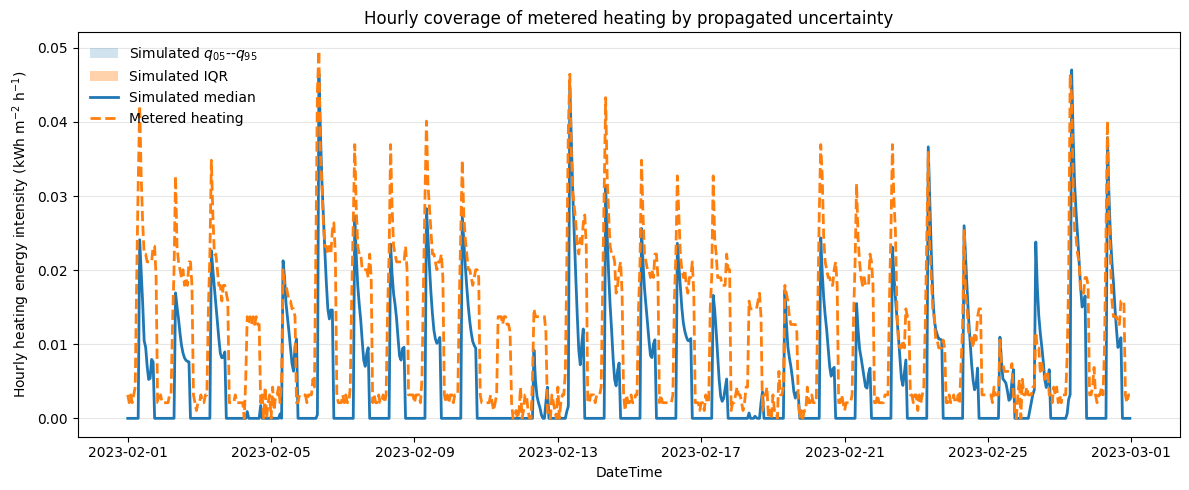

Viewing period: 2023-02-01 00:00:00 to 2023-04-28 00:00:00
Number of matched timesteps: 87
Coverage by q05-q95: 0.0%
Coverage by IQR: 0.0%


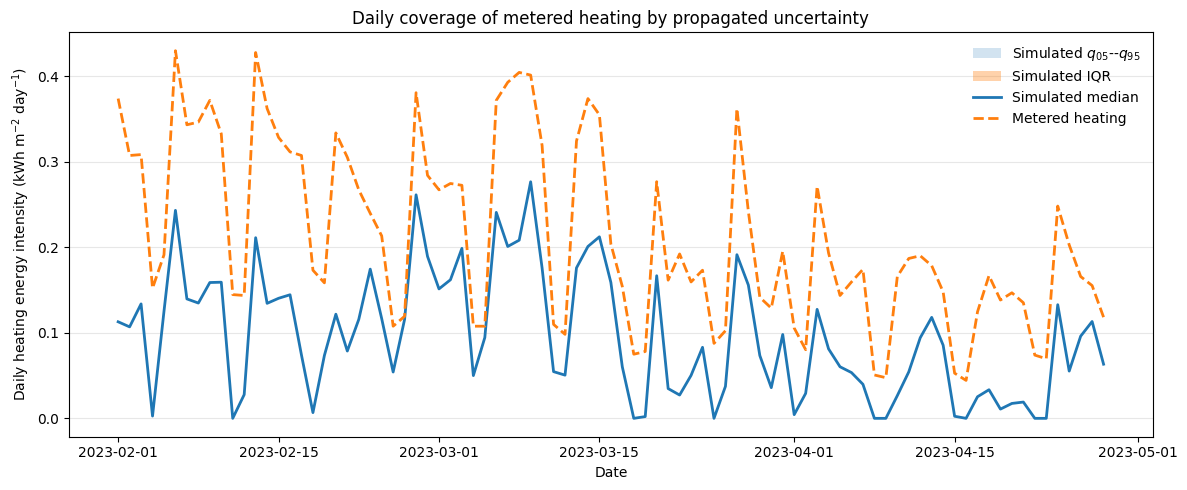

In [14]:
hourly_coverage_feb = plot_heating_coverage(
    sim_summary=hourly_sim_summary,
    meter_series=meter_hourly,
    start_date="2023-02-01 00:00",
    end_date="2023-02-28 23:00",
    time_label="DateTime",
    y_label=r"Hourly heating energy intensity (kWh m$^{-2}$ h$^{-1}$)",
    title="Hourly coverage of metered heating by propagated uncertainty"
)
daily_coverage_feb = plot_heating_coverage(
    sim_summary=daily_sim_summary,
    meter_series=meter_daily,
    start_date="2023-02-01",
    end_date="2023-04-28",
    time_label="Date",
    y_label=r"Daily heating energy intensity (kWh m$^{-2}$ day$^{-1}$)",
    title="Daily coverage of metered heating by propagated uncertainty"
)

# APPENDIX

JSON<br>
└ defines uncertain parameters and their PDFs

DEFAULT_PARAMS<br>
└ defines deterministic fallback values

make_lhs_samples()<br>
└ generates sampled parameter sets

make_zone()<br>
└ injects envelope, capacitance, lighting, setpoints

make_heating_schedule()<br>
└ injects operational heating setpoints

make_ach()<br>
└ injects infiltration and ventilation assumptions

run_model(sampled_params)<br>
└ runs one simulation